Bước làm sạch dữ liệu
- Biến đổi dữ liệu : dữ liệu sau khi biến đổi ở file energy_pannel_wide.csv
- Xử lý NaN và outlier
- Đánh giá dữ liệu = 0

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("processed_data.csv")

# chuẩn hóa tên cột
df.columns = df.columns.str.lower()

print(df.head())

           type  country  year      value  unit
0  total-energy  Algeria  1990  21.166734  Mtep
1  total-energy  Algeria  1991  23.165670  Mtep
2  total-energy  Algeria  1992  24.170773  Mtep
3  total-energy  Algeria  1993  26.026684  Mtep
4  total-energy  Algeria  1994  27.025515  Mtep


In [26]:
clean_data = pd.read_csv("processed_data.csv")
zero_by_type = (
    clean_data[clean_data['Value'] == 0]
    .groupby('Type')
    .size()
    .sort_values(ascending=False)
)

zero_by_type

Type
renewables-wind-solar    358
renewables                58
coal-lignite              57
natural-gas               16
dtype: int64

In [27]:
clean_data_1 = pd.read_csv("energy_panel_wide.csv")
zero_by_type = (
    clean_data_1[clean_data_1['Value'] == 0]
    .groupby('Type')
    .size()
    .sort_values(ascending=False)
)

zero_by_type

KeyError: 'Value'

In [9]:
print("Số country:", df['country'].nunique())
print("Số year:", df['year'].nunique())
print("Số type:", df['type'].nunique())

Số country: 48
Số year: 35
Số type: 8


In [23]:
countries = df['country'].unique()
years = df['year'].unique()
types = df['type'].unique()

full_index = pd.MultiIndex.from_product(
    [countries, years, types],
    names=['country', 'year', 'type']
)

full_panel = pd.DataFrame(index=full_index).reset_index()

In [11]:

merged = full_panel.merge(
    df,
    on=['country', 'year', 'type'],
    how='left'
)

In [12]:
print("Tổng missing value:", merged['value'].isna().sum())

Tổng missing value: 140


In [13]:
#Biến đổi dữ liệu
df_wide = merged.pivot(
    index=['country','year'],
    columns='type',
    values='value'
).reset_index()

In [14]:
df_wide.to_csv("energy_panel_wide.csv", index=False)

In [24]:
import pandas as pd

df_clean = pd.read_csv("energy_panel_wide.csv")
df_clean.head()
missing_by_column = df_clean.isna().sum()

missing_by_column.sort_values(ascending=False)


coal-lignite             70
renewables               35
renewables-wind-solar    35
country                   0
year                      0
co2-emissions             0
natural-gas               0
electricity               0
oil-products              0
total-energy              0
dtype: int64

In [30]:
zero_by_column = (clean_data_1 == 0).sum()

zero_by_column.sort_values(ascending=False)

renewables-wind-solar    358
renewables                58
coal-lignite              57
natural-gas               16
year                       0
country                    0
electricity                0
co2-emissions              0
oil-products               0
total-energy               0
dtype: int64

In [28]:
zero_by_column = (df == 0).sum()

zero_by_column.sort_values(ascending=False)

value      489
type         0
country      0
year         0
unit         0
dtype: int64

In [23]:
missing_summary = (
    merged[merged['value'].isna()]
    .groupby(['country','year'])['type']
    .apply(lambda x: ", ".join(x))
    .reset_index(name='missing_types')
)

print(missing_summary.head(10))


  country  year missing_types
0  Kuwait  1990  coal-lignite
1  Kuwait  1991  coal-lignite
2  Kuwait  1992  coal-lignite
3  Kuwait  1993  coal-lignite
4  Kuwait  1994  coal-lignite
5  Kuwait  1995  coal-lignite
6  Kuwait  1996  coal-lignite
7  Kuwait  1997  coal-lignite
8  Kuwait  1998  coal-lignite
9  Kuwait  1999  coal-lignite


In [24]:
missing_countries = missing_summary['country'].unique()

print("Các nước có thiếu dữ liệu:")
print(missing_countries)

Các nước có thiếu dữ liệu:
['Kuwait' 'Qatar']


In [25]:
for country in missing_countries:
    print("\n======================")
    print(f"Country: {country}")
    print(missing_summary[missing_summary['country'] == country])


Country: Kuwait
   country  year missing_types
0   Kuwait  1990  coal-lignite
1   Kuwait  1991  coal-lignite
2   Kuwait  1992  coal-lignite
3   Kuwait  1993  coal-lignite
4   Kuwait  1994  coal-lignite
5   Kuwait  1995  coal-lignite
6   Kuwait  1996  coal-lignite
7   Kuwait  1997  coal-lignite
8   Kuwait  1998  coal-lignite
9   Kuwait  1999  coal-lignite
10  Kuwait  2000  coal-lignite
11  Kuwait  2001  coal-lignite
12  Kuwait  2002  coal-lignite
13  Kuwait  2003  coal-lignite
14  Kuwait  2004  coal-lignite
15  Kuwait  2005  coal-lignite
16  Kuwait  2006  coal-lignite
17  Kuwait  2007  coal-lignite
18  Kuwait  2008  coal-lignite
19  Kuwait  2009  coal-lignite
20  Kuwait  2010  coal-lignite
21  Kuwait  2011  coal-lignite
22  Kuwait  2012  coal-lignite
23  Kuwait  2013  coal-lignite
24  Kuwait  2014  coal-lignite
25  Kuwait  2015  coal-lignite
26  Kuwait  2016  coal-lignite
27  Kuwait  2017  coal-lignite
28  Kuwait  2018  coal-lignite
29  Kuwait  2019  coal-lignite
30  Kuwait  2020  coal

##  Trực quan hóa cấu trúc Missing theo Country – Year – Type

Để đánh giá phân bố giá trị thiếu trong dữ liệu, biểu đồ heatmap được sử dụng cho từng loại năng lượng (type).

Trong mỗi biểu đồ:

- Trục hoành (x-axis) biểu diễn năm (year).
- Trục tung (y-axis) biểu diễn quốc gia (country).
- Giá trị màu sắc thể hiện trạng thái thiếu dữ liệu:
  - 1 (True): Có missing
  - 0 (False): Không missing

Heatmap giúp xác định:

- Missing có tập trung theo quốc gia hay không,
- Missing có xuất hiện theo chuỗi thời gian hay không,
- Phân biệt giữa structural missing và missing ngẫu nhiên.

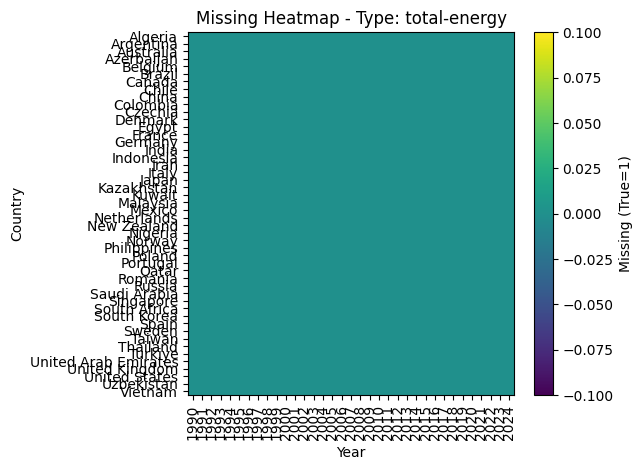

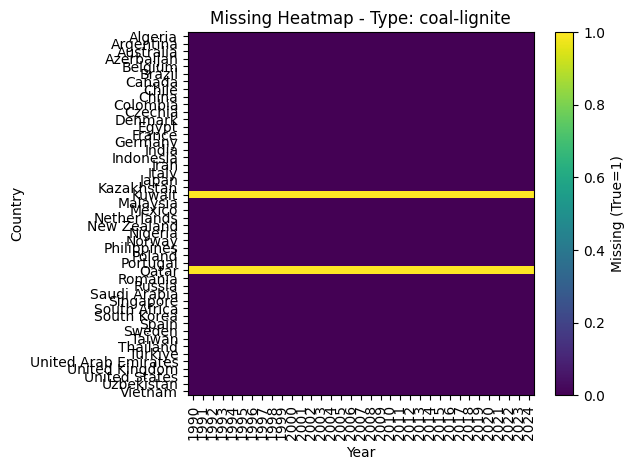

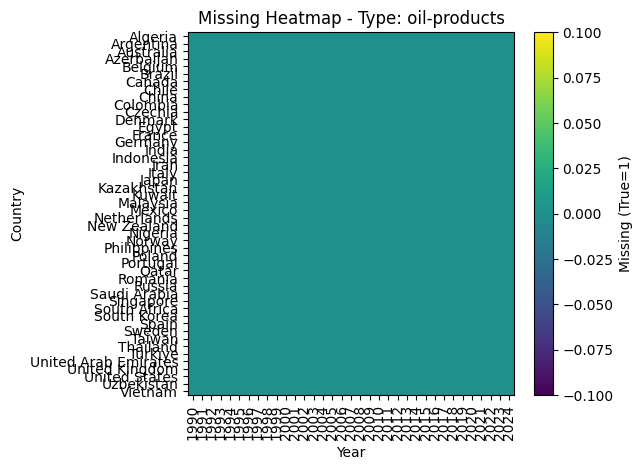

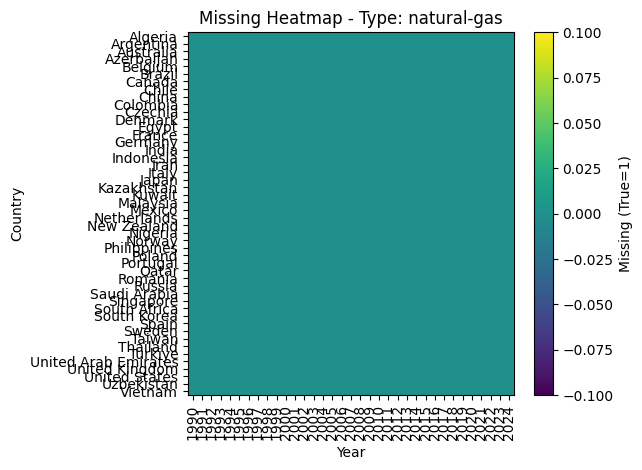

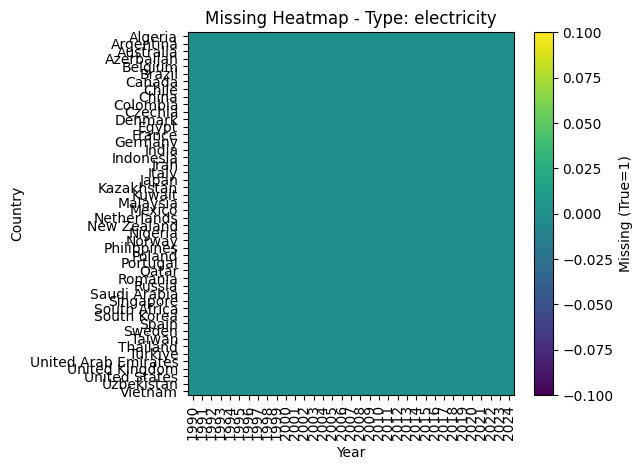

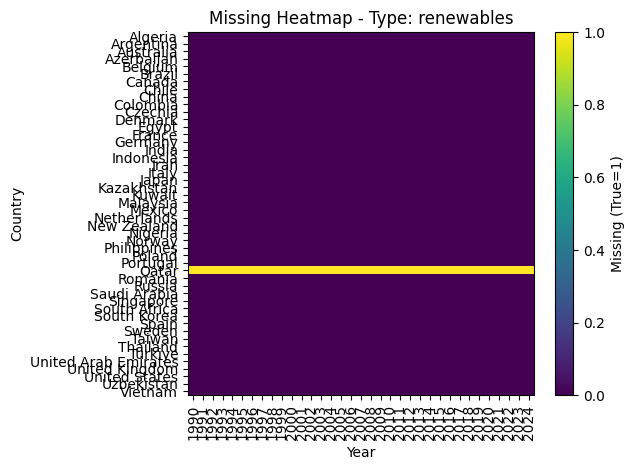

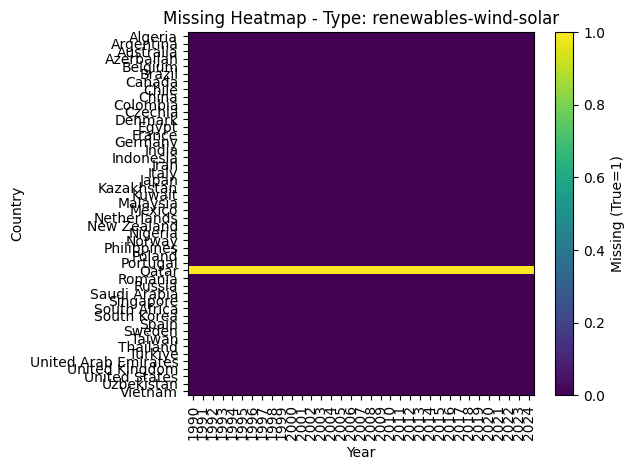

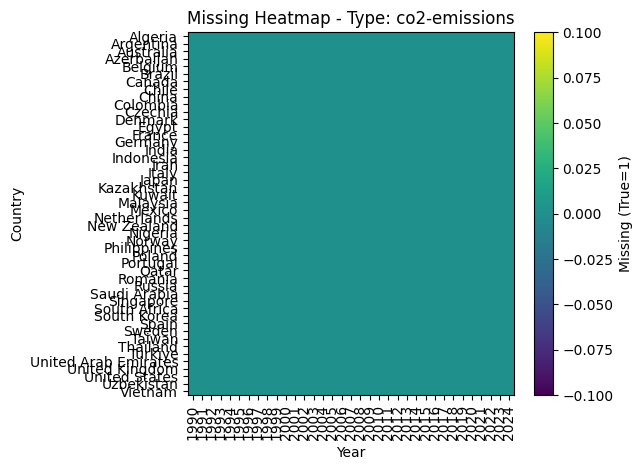

In [26]:
import matplotlib.pyplot as plt

for t in merged['type'].unique():
    
    temp = merged[merged['type'] == t]
    
    matrix = (
        temp.assign(is_missing = temp['value'].isna())
        .pivot(index='country', columns='year', values='is_missing')
    )
    
    plt.figure()
    plt.imshow(matrix, aspect='auto')
    plt.colorbar(label="Missing (True=1)")
    plt.title(f"Missing Heatmap - Type: {t}")
    plt.xlabel("Year")
    plt.ylabel("Country")
    plt.xticks(range(len(matrix.columns)), matrix.columns, rotation=90)
    plt.yticks(range(len(matrix.index)), matrix.index)
    plt.tight_layout()
    plt.show()

In [27]:
missing_ratio_country = (
    merged.assign(is_missing = merged['value'].isna())
    .groupby('country')['is_missing']
    .mean()
    .reset_index(name='missing_ratio')
    .sort_values('missing_ratio', ascending=False)
)

print(missing_ratio_country)

                 country  missing_ratio
31                 Qatar          0.375
21                Kuwait          0.125
0                Algeria          0.000
1              Argentina          0.000
4                Belgium          0.000
5                 Brazil          0.000
2              Australia          0.000
3             Azerbaijan          0.000
8                  China          0.000
9               Colombia          0.000
10               Czechia          0.000
11               Denmark          0.000
12                 Egypt          0.000
13                France          0.000
6                 Canada          0.000
7                  Chile          0.000
15                 India          0.000
14               Germany          0.000
18                 Italy          0.000
16             Indonesia          0.000
19                 Japan          0.000
20            Kazakhstan          0.000
22              Malaysia          0.000
17                  Iran          0.000


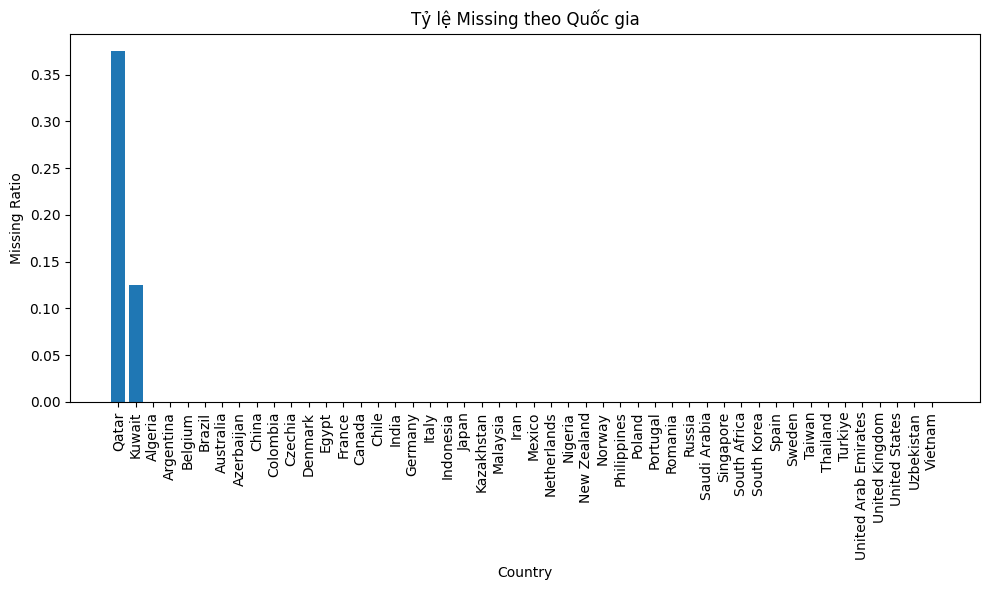

In [ ]:
#Trực quan hóa missing ratio theo quốc gia
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(
    missing_ratio_country['country'],
    missing_ratio_country['missing_ratio']
)

plt.xticks(rotation=90)
plt.ylabel("Missing Ratio")
plt.xlabel("Country")
plt.title("Tỷ lệ Missing theo Quốc gia")

plt.tight_layout()
plt.show()

In [28]:
# missing theo năm hay không
missing_ratio_year = (
    merged.assign(is_missing = merged['value'].isna())
    .groupby('year')['is_missing']
    .mean()
    .reset_index(name='missing_ratio')
)

print(missing_ratio_year)

    year  missing_ratio
0   1990       0.010417
1   1991       0.010417
2   1992       0.010417
3   1993       0.010417
4   1994       0.010417
5   1995       0.010417
6   1996       0.010417
7   1997       0.010417
8   1998       0.010417
9   1999       0.010417
10  2000       0.010417
11  2001       0.010417
12  2002       0.010417
13  2003       0.010417
14  2004       0.010417
15  2005       0.010417
16  2006       0.010417
17  2007       0.010417
18  2008       0.010417
19  2009       0.010417
20  2010       0.010417
21  2011       0.010417
22  2012       0.010417
23  2013       0.010417
24  2014       0.010417
25  2015       0.010417
26  2016       0.010417
27  2017       0.010417
28  2018       0.010417
29  2019       0.010417
30  2020       0.010417
31  2021       0.010417
32  2022       0.010417
33  2023       0.010417
34  2024       0.010417


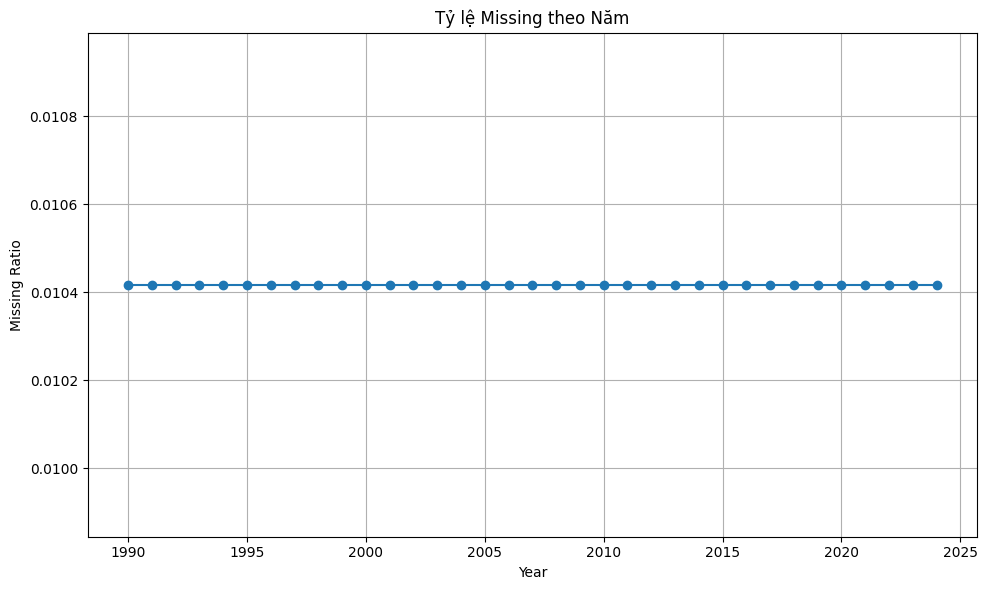

In [ ]:
#Trực quan hóa missing ratio theo năm
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(
    missing_ratio_year['year'],
    missing_ratio_year['missing_ratio'],
    marker='o'
)

plt.xlabel("Year")
plt.ylabel("Missing Ratio")
plt.title("Tỷ lệ Missing theo Năm")

plt.grid(True)
plt.tight_layout()
plt.show()

In [42]:
merged['is_missing'] = merged['value'].isna().astype(int)

In [43]:
import statsmodels.formula.api as smf

model = smf.logit("is_missing ~ C(country) + C(type) + year", data=merged).fit()

print(model.summary())

         Current function value: 0.014055
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:             is_missing   No. Observations:                13440
Model:                          Logit   Df Residuals:                    13384
Method:                           MLE   Df Model:                           55
Date:                Wed, 11 Mar 2026   Pseudo R-squ.:                  0.7573
Time:                        19:46:56   Log-Likelihood:                -188.90
converged:                      False   LL-Null:                       -778.28
Covariance Type:            nonrobust   LLR p-value:                1.417e-210
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                             12.3230        nan        nan        nan         nan      

c:\Users\tranh\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [44]:
# missing theo type ko
missing_ratio_type = (
    merged.assign(is_missing = merged['value'].isna())
    .groupby('type')['is_missing']
    .mean()
    .reset_index(name='missing_ratio')
    .sort_values('missing_ratio', ascending=False)
)

print(missing_ratio_type)

                    type  missing_ratio
1           coal-lignite       0.041667
5             renewables       0.020833
6  renewables-wind-solar       0.020833
0          co2-emissions       0.000000
3            natural-gas       0.000000
2            electricity       0.000000
4           oil-products       0.000000
7           total-energy       0.000000


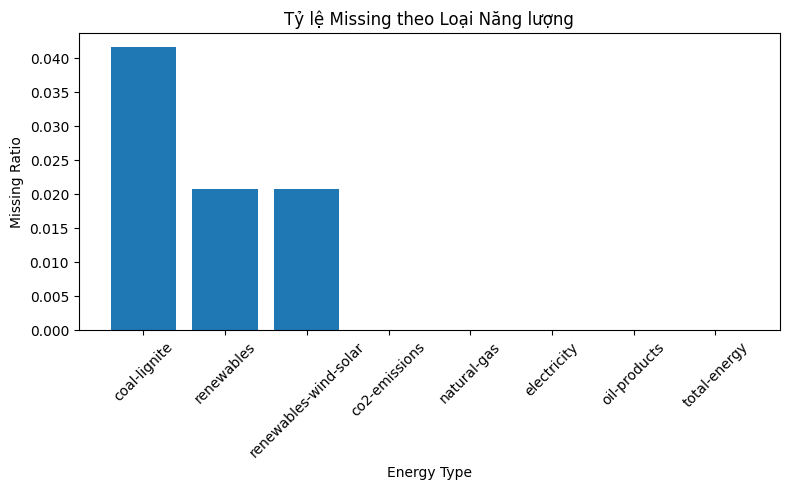

In [45]:
#Trực quan hóa missing ratio theo loại năng lượng
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    missing_ratio_type['type'],
    missing_ratio_type['missing_ratio']
)

plt.xticks(rotation=45)
plt.ylabel("Missing Ratio")
plt.xlabel("Energy Type")
plt.title("Tỷ lệ Missing theo Loại Năng lượng")

plt.tight_layout()
plt.show()

In [46]:
merged.groupby(['country','type'])['is_missing'].mean().sort_values(ascending=False)

country         type                 
Kuwait          coal-lignite             1.0
Qatar           coal-lignite             1.0
                renewables               1.0
                renewables-wind-solar    1.0
United Kingdom  natural-gas              0.0
                                        ... 
Argentina       natural-gas              0.0
                oil-products             0.0
                renewables               0.0
                renewables-wind-solar    0.0
                total-energy             0.0
Name: is_missing, Length: 384, dtype: float64

##  Phân tích missing theo country–type

Từ kết quả tổng hợp missing theo `country–type`, có thể rút ra:

- 100% các năm trong giai đoạn quan sát, **Kuwait** thiếu dữ liệu cho biến **coal-lignite**.
- 100% các năm trong giai đoạn quan sát, **Qatar** thiếu dữ liệu cho các biến:
  - **coal-lignite**
  - **renewables**
  - **renewables-wind-solar**

Điều này cho thấy các tổ hợp country–type trên không có bất kỳ quan sát hợp lệ nào trong toàn bộ chuỗi thời gian.

###  Diễn giải

Dạng thiếu dữ liệu này mang tính **structural missing** (thiếu mang tính cấu trúc), tức là:

- Có thể quốc gia đó không sản xuất hoặc không tiêu thụ loại năng lượng tương ứng.
- Hoặc hệ thống dữ liệu không ghi nhận biến đó cho quốc gia này.

Đây không phải là thiếu dữ liệu ngẫu nhiên, mà phản ánh đặc điểm cấu trúc của hệ thống năng lượng từng quốc gia.
###  Cách xử lý missing

Dựa trên kết quả phân tích, các giá trị thiếu trong dữ liệu mang tính **structural missing** (thiếu mang tính cấu trúc), tức là thiếu hoàn toàn theo từng tổ hợp country–type trong toàn bộ giai đoạn quan sát.

Cụ thể:

- Kuwait thiếu hoàn toàn biến *coal-lignite*.
- Qatar thiếu hoàn toàn các biến *coal-lignite*, *renewables* và *renewables-wind-solar*.

####  Nguyên tắc xử lý

Do missing không mang tính ngẫu nhiên (không phải MCAR), mà phản ánh đặc điểm cấu trúc năng lượng của từng quốc gia, nên:

- Không thực hiện nội suy (interpolation).
- Không thay thế bằng giá trị trung bình hoặc ước lượng.
- Không loại bỏ toàn bộ quốc gia khỏi dữ liệu.
- Giữ nguyên giá trị NaN trong bộ dữ liệu.

####  Lý do

Việc điền giá trị giả định có thể làm sai lệch bản chất kinh tế của dữ liệu.  
Giữ nguyên missing giúp đảm bảo:

- Tính trung thực của dữ liệu gốc.
- Phản ánh đúng cấu trúc năng lượng từng quốc gia.
- Tránh tạo ra thông tin giả trong quá trình phân tích hoặc mô hình hóa.

Do đó, các giá trị thiếu được giữ nguyên và sẽ được xử lý phù hợp trong từng bước phân tích/mô hình (ví dụ: tự động loại bỏ khi ước lượng mô hình hồi quy).


Xử lý outlier

In [35]:
def detect_panel_outliers(df):
    outliers = []
    
    for (c,t), group in df.groupby(['country','type']):
        Q1 = group['value'].quantile(0.25)
        Q3 = group['value'].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5*IQR
        upper = Q3 + 1.5*IQR
        
        temp_out = group[(group['value'] < lower) | (group['value'] > upper)]
        outliers.append(temp_out)
    
    return pd.concat(outliers)

panel_outliers = detect_panel_outliers(merged.dropna(subset=['value']))

print("Panel outliers:", len(panel_outliers))

Panel outliers: 376


## Xử lý Outlier trong dữ liệu

###  Kiểm tra Outlier

Outlier được kiểm tra theo từng tổ hợp **country–type** nhằm tránh so sánh sai lệch giữa các quốc gia có quy mô kinh tế khác nhau. 

Phương pháp IQR (Interquartile Range) được sử dụng để phát hiện các giá trị nằm ngoài khoảng:

Q1 − 1.5×IQR và Q3 + 1.5×IQR.

Kết quả cho thấy một số quan sát được đánh dấu là outlier. Tuy nhiên, các giá trị này chủ yếu xuất hiện ở:

- Các quốc gia có quy mô tiêu thụ lớn (ví dụ: Trung Quốc, Hoa Kỳ),
- Hoặc các năm gần đây khi xu hướng tiêu thụ tăng mạnh.

---

###  Diễn giải

Do dữ liệu năng lượng có đặc điểm:

- Phân phối lệch phải (right-skewed),
- Khác biệt lớn về quy mô giữa các quốc gia,
- Có xu hướng tăng theo thời gian,

nên các giá trị bị đánh dấu là outlier phần lớn phản ánh sự khác biệt kinh tế thực tế, không phải lỗi dữ liệu.

---

###  Quyết định xử lý

Vì vậy:

- Không loại bỏ các quan sát bị đánh dấu là outlier.
- Không thực hiện winsorization hoặc cắt bỏ dữ liệu.
- Không thay thế bằng giá trị trung bình.

Thay vào đó, để giảm ảnh hưởng của phân phối lệch và giá trị cực lớn, dữ liệu được biến đổi log:


In [ ]:
# Kiểm tra dữ liệu = 0
zero_ratio = (
    (df_wide == 0)
    .groupby(df_wide['country'])
    .mean()
)

print(zero_ratio)

type                  country  year  co2-emissions  coal-lignite  electricity  \
country                                                                         
Algeria                   0.0   0.0            0.0      0.028571          0.0   
Argentina                 0.0   0.0            0.0      0.000000          0.0   
Australia                 0.0   0.0            0.0      0.000000          0.0   
Azerbaijan                0.0   0.0            0.0      0.371429          0.0   
Belgium                   0.0   0.0            0.0      0.000000          0.0   
Brazil                    0.0   0.0            0.0      0.000000          0.0   
Canada                    0.0   0.0            0.0      0.000000          0.0   
Chile                     0.0   0.0            0.0      0.000000          0.0   
China                     0.0   0.0            0.0      0.000000          0.0   
Colombia                  0.0   0.0            0.0      0.000000          0.0   
Czechia                   0.

In [39]:
merged.groupby(['country','type'])['value'].apply(lambda x: (x==0).all())

country  type                 
Algeria  co2-emissions            False
         coal-lignite             False
         electricity              False
         natural-gas              False
         oil-products             False
                                  ...  
Vietnam  natural-gas              False
         oil-products             False
         renewables               False
         renewables-wind-solar    False
         total-energy             False
Name: value, Length: 384, dtype: bool

##  Xử lý giá trị bằng 0 trong dữ liệu

### Kiểm tra giá trị bằng 0

Dữ liệu được kiểm tra nhằm xác định xem có tồn tại trường hợp nào mà một tổ hợp **quốc gia – loại năng lượng** có giá trị bằng 0 trong toàn bộ giai đoạn quan sát hay không.

Kết quả cho thấy:

- Không có quốc gia nào có một loại năng lượng mà toàn bộ các năm đều bằng 0.
- Các giá trị bằng 0 xuất hiện rải rác theo thời gian, không mang tính hệ thống.

---

### Diễn giải

Điều này cho thấy các giá trị bằng 0 nhiều khả năng phản ánh:

- Thực tế kinh tế (không sản xuất hoặc không tiêu thụ loại năng lượng đó trong năm cụ thể),
- Hoặc mức tiêu thụ/sản xuất rất thấp trong một số năm.

Các giá trị này **không phải là lỗi nhập liệu**, cũng không mang tính thiếu dữ liệu.

---

###  Quyết định xử lý

Do đó:

- Giá trị bằng 0 được xem là quan sát hợp lệ.
- Không chuyển đổi giá trị 0 thành giá trị thiếu (NaN).
- Không loại bỏ các quan sát có giá trị bằng 0 khỏi bộ dữ liệu.

Việc giữ nguyên giá trị 0 giúp đảm bảo tính trung thực và phản ánh đúng đặc điểm kinh tế – năng lượng của từng quốc gia trong từng năm.